In [4]:
import wandb

api = wandb.Api()

# List all runs in your project
runs = api.runs("weissma6-zhaw-school-of-engineering/UR10_pick_ppo")

print("Available runs:")
for run in runs:
    print(f"  ID: {run.id}  |  Name: {run.name}  |  State: {run.state}")


'''
This will show you the exact run IDs. Common issues:

1. **Run name ≠ Run ID** — W&B has both `run.name` (display name) and `run.id` (unique identifier). You might be using the name instead of the ID.

2. **Check in W&B UI** — Go to your run's page, the URL will §be:

https://wandb.ai/weissma6/UR10_pick_ppo/runs/<actual_run_id>
'''

Available runs:
  ID: ps4ihqb6  |  Name: Test new geometry  |  State: finished
  ID: 1zp7tde5  |  Name: Tiny1  |  State: finished
  ID: 8usag8a4  |  Name: Tiny1  |  State: finished
  ID: m835o1hp  |  Name: fast  |  State: finished
  ID: quickest_20260117_092424_623  |  Name: quickest_20260117_092424_623  |  State: finished
  ID: meaningful_video_20260117_102721_4575  |  Name: meaningful_video_20260117_102721_4575  |  State: finished
  ID: ncwu81wk  |  Name: default_short_seed 1  |  State: finished
  ID: el7qkkoe  |  Name: default_short_seed 1  |  State: finished
  ID: j2lk3gxw  |  Name: default_short_seed 1  |  State: finished
  ID: ikfi821b  |  Name: default_short_1k  |  State: finished
  ID: gjvguk4x  |  Name: default_short_seed 100k  |  State: finished
  ID: sweep_part2_1028_20260117_170531_7924  |  Name: sweep_part2_1028_20260117_170531_7924  |  State: finished
  ID: baseling_fast_20260118_104318_2201  |  Name: baseling_fast_20260118_104318_2201  |  State: finished
  ID: baseling_2

"\nThis will show you the exact run IDs. Common issues:\n\n1. **Run name ≠ Run ID** — W&B has both `run.name` (display name) and `run.id` (unique identifier). You might be using the name instead of the ID.\n\n2. **Check in W&B UI** — Go to your run's page, the URL will §be:\n\nhttps://wandb.ai/weissma6/UR10_pick_ppo/runs/<actual_run_id>\n"

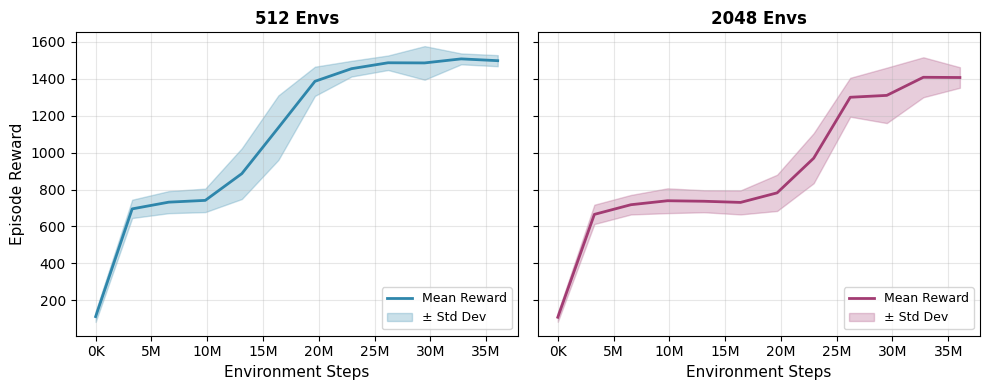

In [6]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Fetch data from W&B ---
api = wandb.Api()
user = "weissma6-zhaw-school-of-engineering"
project = "UR10_pick_ppo"
runs = {
    "512 Envs": "lift_512Envs_20260124_164012_5264",
    "2048 Envs": "lift_2048Envs_20260124_163951_172",
}

data = {}
for label, run_id in runs.items():
    run = api.run(f"{user}/{project}/{run_id}")
    history = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"])
    history = history.dropna()  # Remove NaN rows
    data[label] = history

# --- Plot ---
fig, axes = plt.subplots(1, len(runs), figsize=(5 * len(runs), 4), sharey=True)

# Color palette (adjust as needed)
colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]

for ax, (label, df), color in zip(axes, data.items(), colors):
    steps = df["_step"] if "_step" in df.columns else df.index
    mean = df["eval/episode_reward"]
    std = df["eval/episode_reward_std"]
    
    # Plot mean line
    ax.plot(steps, mean, color=color, linewidth=2, label="Mean Reward")
    
    # Plot std band
    ax.fill_between(
        steps,
        mean - std,
        mean + std,
        color=color,
        alpha=0.25,
        label="± Std Dev"
    )
    
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)

    # Format x-axis with millions
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
    )

axes[0].set_ylabel("Episode Reward", fontsize=11)

plt.tight_layout()
plt.savefig("reward_comparison.pdf", bbox_inches="tight", dpi=300)
plt.savefig("reward_comparison.png", bbox_inches="tight", dpi=300)
plt.show()